# Deep Convolutional Generative Adversarial Network (DCGAN)

After mastering classical CNN models, we turn ourselves to generative models and especially to Generative Adversarial Networks. This notebook is a DCGAN implementation with TensorFlow and Keras, trained with the Fashion-MNIST data set to generates gray-scale 28x28x1 images.

Link to the DCGAN paper: Unsupervised Representation Learning with Deep Convolutional Generative Adversarial Networks https://arxiv.org/abs/1511.06434.

Credits: Based on a notebook from Margaret Maynard-Reid ([@margaretmz](https://twitter.com/margaretmz))

Run the notebook in Google colab: https://colab.research.google.com/github/heprom/cvml/blob/main/corrections/fashion_mnist_cor.ipynb

In [1]:
import tensorflow as tf
print(tf.version.VERSION)

from tensorflow import keras
from tensorflow.keras.datasets import fashion_mnist
from tensorflow.keras.models import Sequential
from tensorflow.keras import layers
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam

from matplotlib import pyplot as plt
import numpy as np

2.19.0


## Prepare Fashion-MNIST data
The first step is to get data ready for training.


### Loading

The data can be loaded directly from `keras`. Use the function `tf.keras.datasets.fashion_mnist.load_data()` to do this. The class names corresponding to the labels are not useful directly but can be used in data visualization.

In [2]:
# load the Fashion MNIST dataset
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.fashion_mnist.load_data()

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [4]:
labels = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat', 'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']

There are 60,000 training gray scale images in Fashion-MNIST.

In [5]:
x_train.shape

(60000, 28, 28)

In [6]:
type(x_train), x_train.dtype

(numpy.ndarray, dtype('uint8'))

### Visualization

It is always good practice to visualize the training data to get an idea of what the images look like. Here we pick a set of images randomy and display them with the number of their class.

In [45]:
def display_image_row(x, y=None, n_images=None, cm='binary', title=None):
    if not n_images:
        n_images = len(x)
    fig, axes = plt.subplots(1, n_images)
    fig.set_size_inches(12, 2)
    for i in range(n_images):
        ax = axes[i]
        ax.set_axis_off()
        ax.imshow(x[i], cmap=cm)
        if y is not None:
            ax.set_title(y[i])
    if title:
      plt.suptitle(title)

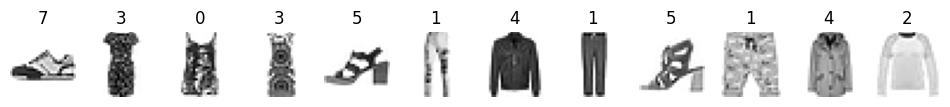

In [8]:
n_images = 12
index_images = np.random.randint(low=0, high=len(x_train) - n_images, size=n_images)
display_image_row(x_train[index_images], y_train[index_images], n_images=None, cm='binary')

### Preprocessing

In [9]:
# reshape data and also convert the data type to 'float32'
print(x_train.shape)
train_images = x_train.reshape(x_train.shape[0], 28, 28, 1).astype('float32')
print(train_images.shape)

# normalize the images to [-1, 1] which is the range of the tanh activation
train_images = (train_images - 127.5) / 127.5
print(train_images.min(), train_images.max())

(60000, 28, 28)
(60000, 28, 28, 1)
-1.0 1.0


## The generator model

Define the generator model architecture with the Keras `Sequential` API.

Use `ReLU` except for the last layer which has `tanh` as activation function.

The job of the generator is to create images from a random vector. To do so in DCGAN, we feed random noise as input to the generator and upsample till the desired image size becomes 28x28x1.

In [10]:
# latent dimension of the random noise
LATENT_DIM = 100

# weight initializer for G per DCGAN paper
WEIGHT_INIT = tf.keras.initializers.RandomNormal(mean=0.0, stddev=0.02)

# number of channels, 1 for gray scale and 3 for color images
CHANNELS = 1

In [11]:
def build_generator():
    # create a Keras Sequential model
    model = Sequential(name='generator')

    # the input is a vector of random noise
    model.add(layers.Input((LATENT_DIM,)))

    # prepare for reshape: FC => BN => RELU layers
    model.add(layers.Dense(7 * 7 * 256))
    model.add(layers.BatchNormalization())
    model.add(layers.ReLU())

    # 1D => 3D: reshape the output of the previous layer
    model.add(layers.Reshape((7, 7, 256)))

    # upsample to 14x14: apply a transposed CONV => BN => RELU
    model.add(layers.Conv2DTranspose(128, (5, 5), strides=(2, 2),padding='same', kernel_initializer=WEIGHT_INIT))
    model.add(layers.BatchNormalization())
    model.add((layers.ReLU()))

    # upsample to 28x28: apply a transposed CONV => BN => RELU
    model.add(layers.Conv2DTranspose(64, (5, 5), strides=(2, 2),padding='same', kernel_initializer=WEIGHT_INIT))
    model.add(layers.BatchNormalization())
    model.add((layers.ReLU()))

    # final layer: Conv2D with tanh activation
    model.add(layers.Conv2D(CHANNELS, (5, 5), padding='same', activation='tanh'))

    # return the generator model
    return model

In [12]:
# build the generator model
generator = build_generator()

In [13]:
generator.summary()

Model: "generator"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 12544)          │     1,266,944 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 12544)          │        50,176 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu (ReLU)                    │ (None, 12544)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape (Reshape)               │ (None, 7, 7, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose                │ (None, 14, 14, 128)    │       819,328 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 14, 14, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_1 (ReLU)                  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_1              │ (None, 28, 28, 64)     │       204,864 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 28, 28, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_2 (ReLU)                  │ (None, 28, 28, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 28, 28, 1)      │         1,601 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,343,681 (8.94 MB)

 Trainable params: 2,318,209 (8.84 MB)

 Non-trainable params: 25,472 (99.50 KB)

## The discriminator model

Define the discriminator model architecture with the Keras `Sequential` API. The final model output is a single neuron with a sigmoid activation.

In [14]:
def build_discriminator(width, height, depth, alpha=0.2):
    # create a Keras Sequential model
    model = Sequential(name='discriminator')

    # the input is an image with a certain depth (1 for gray level, 3 for color images)
    model.add(layers.Input((width, height, depth)))

    # first set of CONV => BN => leaky ReLU layers
    model.add(layers.Conv2D(64, (5, 5), strides=(2, 2), padding='same'))
    model.add(layers.BatchNormalization())
    model.add(layers.LeakyReLU(negative_slope=alpha))

    # second set of CONV => BN => leacy ReLU layers
    model.add(layers.Conv2D(128, (5, 5), strides=(2, 2), padding='same'))
    model.add(layers.BatchNormalization())
    model.add(layers.LeakyReLU(negative_slope=alpha))

    # flatten and apply dropout
    model.add(layers.Flatten())
    model.add(layers.Dropout(0.3))

    # sigmoid in the last layer outputs a single value for binary classification
    model.add(layers.Dense(1, activation='sigmoid'))

    # return the discriminator model
    return model

In [15]:
# build the discriminator model
discriminator = build_discriminator(28, 28, 1)

In [16]:
discriminator.summary()

Model: "discriminator"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_1 (Conv2D)               │ (None, 14, 14, 64)     │         1,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 14, 14, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu (LeakyReLU)         │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 7, 7, 128)      │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 7, 7, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_1 (LeakyReLU)       │ (None, 7, 7, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 6272)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 6272)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │         6,273 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 213,633 (834.50 KB)

 Trainable params: 213,249 (833.00 KB)

 Non-trainable params: 384 (1.50 KB)

## Define `DCGAN` class: override `train_step`
Subclass `keras.Model` and override `train_step` to implement the DCGAN architecture. This is where the magic happens and the heart of the DCGAN implementation.

**The discriminator loss** includes both the loss from the real images and the loss from the fake images.  
**The generator loss** is calculated only with the fake images.


In [17]:
class DCGAN(keras.Model):

    def __init__(self, discriminator, generator, latent_dim):
        super().__init__()
        self.discriminator = discriminator
        self.generator = generator
        self.latent_dim = latent_dim
        self.d_loss_metric = keras.metrics.Mean(name='d_loss')
        self.g_loss_metric = keras.metrics.Mean(name='g_loss')

    def compile(self, d_optimizer, g_optimizer, loss_fn):
        super(DCGAN, self).compile()
        self.d_optimizer = d_optimizer
        self.g_optimizer = g_optimizer
        self.loss_fn = loss_fn

    @property
    def metrics(self):
        return [self.d_loss_metric, self.g_loss_metric]

    def train_step(self, real_images):

        batch_size = tf.shape(real_images)[0]
        noise = tf.random.normal(shape=(batch_size, self.latent_dim))

        # Step 1. Train the discriminator with both real images (label as 1) and fake images (classified as label as 0)
        with tf.GradientTape() as tape:
            # Compute discriminator loss on real images
            pred_real = self.discriminator(real_images, training=True)
            d_loss_real = self.loss_fn(tf.ones((batch_size, 1)), pred_real)

            # Compute discriminator loss on fake images
            fake_images = self.generator(noise)
            pred_fake = self.discriminator(fake_images, training=True)
            d_loss_fake = self.loss_fn(tf.zeros((batch_size, 1)), pred_fake)

            # total discriminator loss
            d_loss = (d_loss_real + d_loss_fake)/2

        # Compute discriminator gradients
        grads = tape.gradient(d_loss, self.discriminator.trainable_variables)
        # Update discriminator weights
        self.d_optimizer.apply_gradients(zip(grads, self.discriminator.trainable_variables))

        # Step 2. Train the generator (do not update weights of the discriminator)
        # G wants D to think the fake images are real (label as 1)
        misleading_labels = tf.ones((batch_size, 1))

        with tf.GradientTape() as tape:
            fake_images = self.generator(noise, training=True)
            pred_fake = self.discriminator(fake_images, training=True)
            g_loss = self.loss_fn(misleading_labels, pred_fake)

        # Compute generator gradients
        grads = tape.gradient(g_loss, self.generator.trainable_variables)
        # Update generator weights
        self.g_optimizer.apply_gradients(zip(grads, self.generator.trainable_variables))

        self.d_loss_metric.update_state(d_loss)
        self.g_loss_metric.update_state(g_loss)

        return {'d_loss': self.d_loss_metric.result(), 'g_loss': self.g_loss_metric.result()}

## Use Keras `Callback` to monitor training

The nice thing about overriding `train_step` of `keras.Model` is that we can subclass the class `Callback` to monitor our DCGAN training. To this end we create a class `GANMonitor` from which an instance will be passed to the `fit` function of the model.

In this GANMonitor, we use the seed noise to create images (with the generator model) throughout the training to visually inspect the progress of the generator. We can also save the generator model at the end of the training which could potentially be used for inference later.

In [31]:
class GANMonitor(keras.callbacks.Callback):
    def __init__(self, num_img=3, latent_dim=100):
        self.num_img = num_img
        self.latent_dim = latent_dim

        # create random noise seed for visualization during training
        self.seed = tf.random.normal([16, latent_dim])

    def on_epoch_end(self, epoch, logs=None):
        generated_images = self.model.generator(self.seed)
        generated_images = (generated_images * 127.5) + 127.5
        generated_images.numpy()

        fig = plt.figure(figsize=(4, 4))
        for i in range(self.num_img):
            plt.subplot(4, 4, i+1)
            img = keras.utils.array_to_img(generated_images[i])
            plt.imshow(img, cmap='gray')
            plt.axis('off')
        plt.savefig('epoch_{:03d}.png'.format(epoch))
        plt.show()

    def on_train_end(self, logs=None):
        self.model.generator.save('generator.keras')

## Train the DCGAN model

Compile the `dcgan` model, with the `Adam` optimizer, learning rate of 0.0002, and the **Binary Cross Entropy** loss functionas recommended by the paper. In future GAN tutorials, you will learn other loss functions for other GAN variants.

Putting together the `dcgan` model.

In [19]:
dcgan = DCGAN(discriminator=discriminator, generator=generator, latent_dim=LATENT_DIM)

Compile the `dcgan` model.

In [20]:
LR = 0.0002 # learning rate

dcgan.compile(
    d_optimizer=keras.optimizers.Adam(learning_rate=LR, beta_1 = 0.5),
    g_optimizer=keras.optimizers.Adam(learning_rate=LR, beta_1 = 0.5),
    loss_fn=keras.losses.BinaryCrossentropy(),
)

Now we simply call `model.fit()` to traing the `dcgan` model!

Epoch 1/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - d_loss: 0.6633 - g_loss: 0.8105

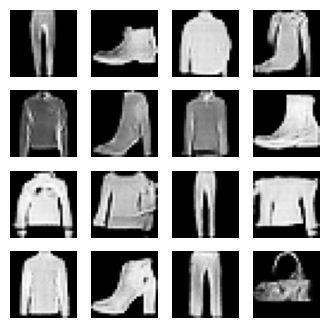

1875/1875 ━━━━━━━━━━━━━━━━━━━━ 28s 15ms/step - d_loss: 0.6633 - g_loss: 0.8105
Epoch 2/10
1874/1875 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - d_loss: 0.6640 - g_loss: 0.8120

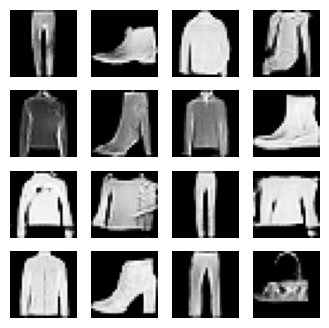

1875/1875 ━━━━━━━━━━━━━━━━━━━━ 27s 15ms/step - d_loss: 0.6640 - g_loss: 0.8120
Epoch 3/10
1874/1875 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - d_loss: 0.6647 - g_loss: 0.8095

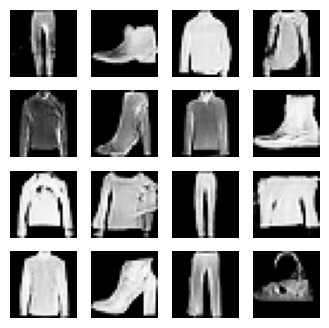

1875/1875 ━━━━━━━━━━━━━━━━━━━━ 27s 14ms/step - d_loss: 0.6647 - g_loss: 0.8095
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - d_loss: 0.6643 - g_loss: 0.8087

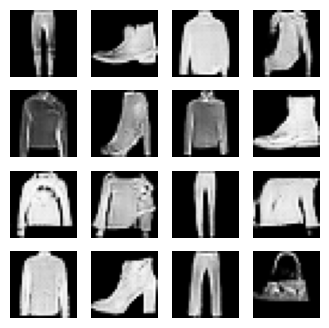

1875/1875 ━━━━━━━━━━━━━━━━━━━━ 27s 15ms/step - d_loss: 0.6643 - g_loss: 0.8087
Epoch 5/10
1872/1875 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - d_loss: 0.6644 - g_loss: 0.8084

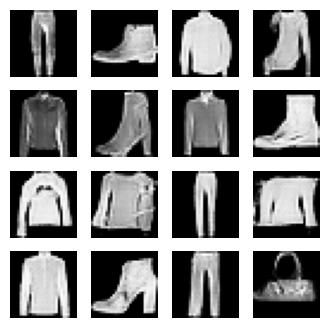

1875/1875 ━━━━━━━━━━━━━━━━━━━━ 28s 15ms/step - d_loss: 0.6644 - g_loss: 0.8084
Epoch 6/10
1874/1875 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - d_loss: 0.6631 - g_loss: 0.8138

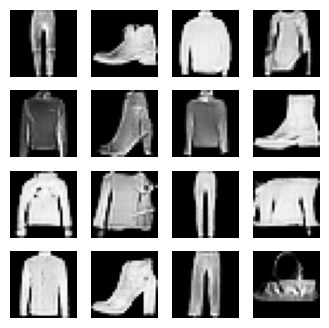

1875/1875 ━━━━━━━━━━━━━━━━━━━━ 27s 15ms/step - d_loss: 0.6631 - g_loss: 0.8138
Epoch 7/10
1872/1875 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - d_loss: 0.6654 - g_loss: 0.8126

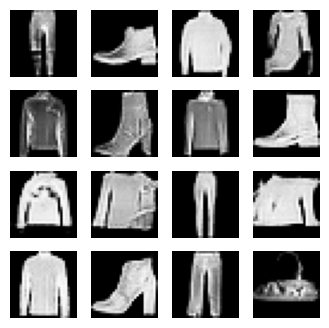

1875/1875 ━━━━━━━━━━━━━━━━━━━━ 27s 15ms/step - d_loss: 0.6654 - g_loss: 0.8126
Epoch 8/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - d_loss: 0.6649 - g_loss: 0.8184

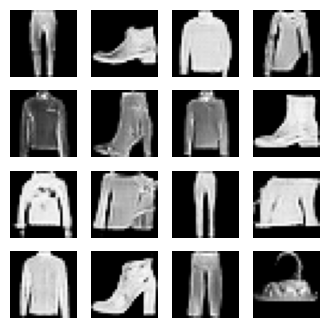

1875/1875 ━━━━━━━━━━━━━━━━━━━━ 27s 15ms/step - d_loss: 0.6649 - g_loss: 0.8184
Epoch 9/10
1872/1875 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - d_loss: 0.6644 - g_loss: 0.8145

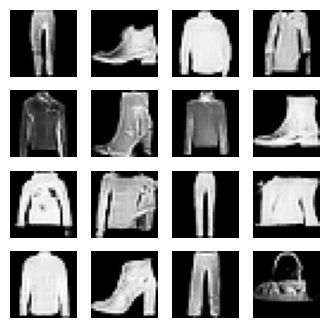

1875/1875 ━━━━━━━━━━━━━━━━━━━━ 27s 15ms/step - d_loss: 0.6644 - g_loss: 0.8145
Epoch 10/10
1872/1875 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - d_loss: 0.6625 - g_loss: 0.8142

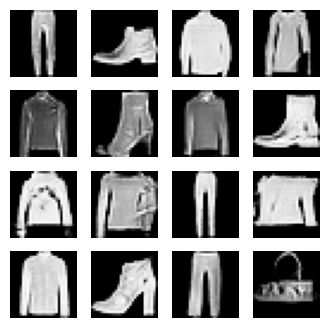

1875/1875 ━━━━━━━━━━━━━━━━━━━━ 28s 15ms/step - d_loss: 0.6625 - g_loss: 0.8142


In [32]:
NUM_EPOCHS = 10 # number of epochs
fit = dcgan.fit(train_images, epochs=NUM_EPOCHS, callbacks=[GANMonitor(num_img=16, latent_dim=LATENT_DIM)])

In [35]:
fit.history

{'d_loss': [0.6661327481269836,
  0.6645870804786682,
  0.665141761302948,
  0.664941668510437,
  0.6656357049942017,
  0.6635573506355286,
  0.6653504371643066,
  0.6654539704322815,
  0.6657071709632874,
  0.66444331407547],
 'g_loss': [0.8092977404594421,
  0.8093839883804321,
  0.8077933192253113,
  0.807880699634552,
  0.8064115643501282,
  0.8114016056060791,
  0.81219881772995,
  0.8128595948219299,
  0.8124344348907471,
  0.8124858140945435]}

In [25]:
# save our generator model for later use
dcgan.generator.save('fashion_mnist_generator.keras')

In [ ]:
# we can also save the whole model
dcgan.save('dcgan_fashion_mnist.keras')

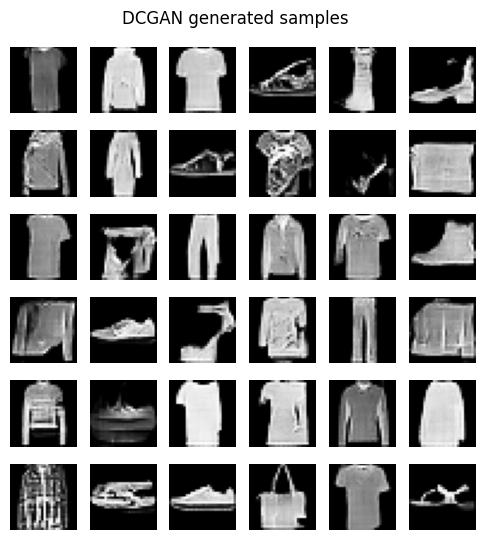

In [26]:
# now make some prediction with our newly trained model
seeds = tf.random.normal([36, LATENT_DIM])
samples = ((dcgan.generator(seeds) * 127.5) + 127.5).numpy()

fig = plt.figure(figsize=(6, 6))
for i in range(36):
    plt.subplot(6, 6, i+1)
    img = keras.utils.array_to_img(samples[i])
    plt.imshow(img, cmap='gray')
    plt.axis('off')
fig.subplots_adjust(top=0.92)
plt.suptitle('DCGAN generated samples')
plt.show()

(7, 28, 28, 1)


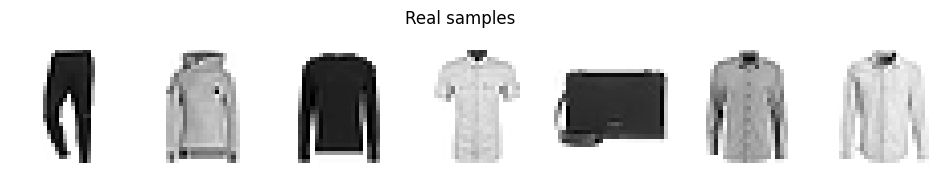

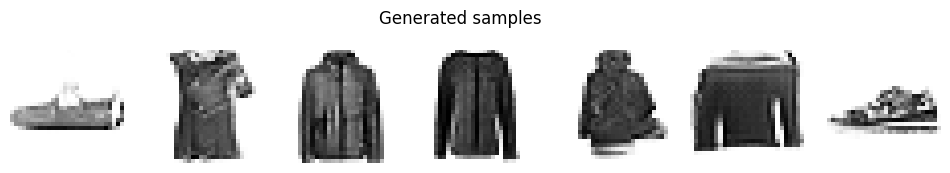

In [47]:
n = 7
seeds = tf.random.normal([n, LATENT_DIM])
samples = ((dcgan.generator(seeds) * 127.5) + 127.5).numpy()
print(samples.shape)
index_images = np.random.randint(low=0, high=len(x_train) - n, size=n)
display_image_row(x_train[index_images], n_images=None, title='Real samples')
display_image_row(samples, n_images=None, title='Generated samples')

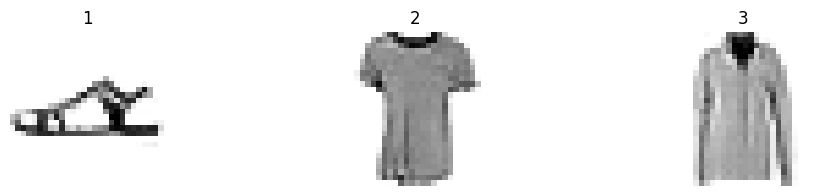

In [28]:
display_image_row(samples, [1, 2, 3], n_images=None, cm='binary')

Check if the discriminator is able to tell that these are fake images.

In [30]:
np.round(discriminator.predict(samples))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step


array([[0.],
       [0.],
       [0.]], dtype=float32)